In [5]:
# Data manipulation and analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [6]:
# Load water quality training dataset
water_quality = pd.read_csv('../Provided Datasets/water_quality_training_dataset.csv')

print("Water Quality Dataset Info:")
print(f"Shape: {water_quality.shape}")
print(f"\nColumns: {list(water_quality.columns)}")
print(f"\nMissing values:")
print(water_quality[['Total Alkalinity', 'Electrical Conductance', 'Dissolved Reactive Phosphorus']].isnull().sum())

Water Quality Dataset Info:
Shape: (9319, 6)

Columns: ['Latitude', 'Longitude', 'Sample Date', 'Total Alkalinity', 'Electrical Conductance', 'Dissolved Reactive Phosphorus']

Missing values:
Total Alkalinity                 0
Electrical Conductance           0
Dissolved Reactive Phosphorus    0
dtype: int64



TOTAL ALKALINITY
  Count: 9319
  Mean: 119.1082
  Median: 113.3000
  Std: 74.6926
  Min: 4.8000
  Max: 361.6760
  Skewness: 0.5361 (right-skewed)
  Kurtosis: -0.2529
  Mean-Median difference: 5.8082 (4.88% of mean)

DISSOLVED REACTIVE PHOSPHORUS
  Count: 9319
  Mean: 43.5253
  Median: 20.0000
  Std: 50.9802
  Min: 5.0000
  Max: 195.0000
  Skewness: 1.6444 (right-skewed)
  Kurtosis: 1.3324
  Mean-Median difference: 23.5253 (54.05% of mean)

ELECTRICAL CONDUCTANCE
  Count: 9319
  Mean: 485.0041
  Median: 402.0000
  Std: 341.9377
  Min: 15.1200
  Max: 1506.0000
  Skewness: 0.9293 (right-skewed)
  Kurtosis: 0.2893
  Mean-Median difference: 83.0041 (17.11% of mean)


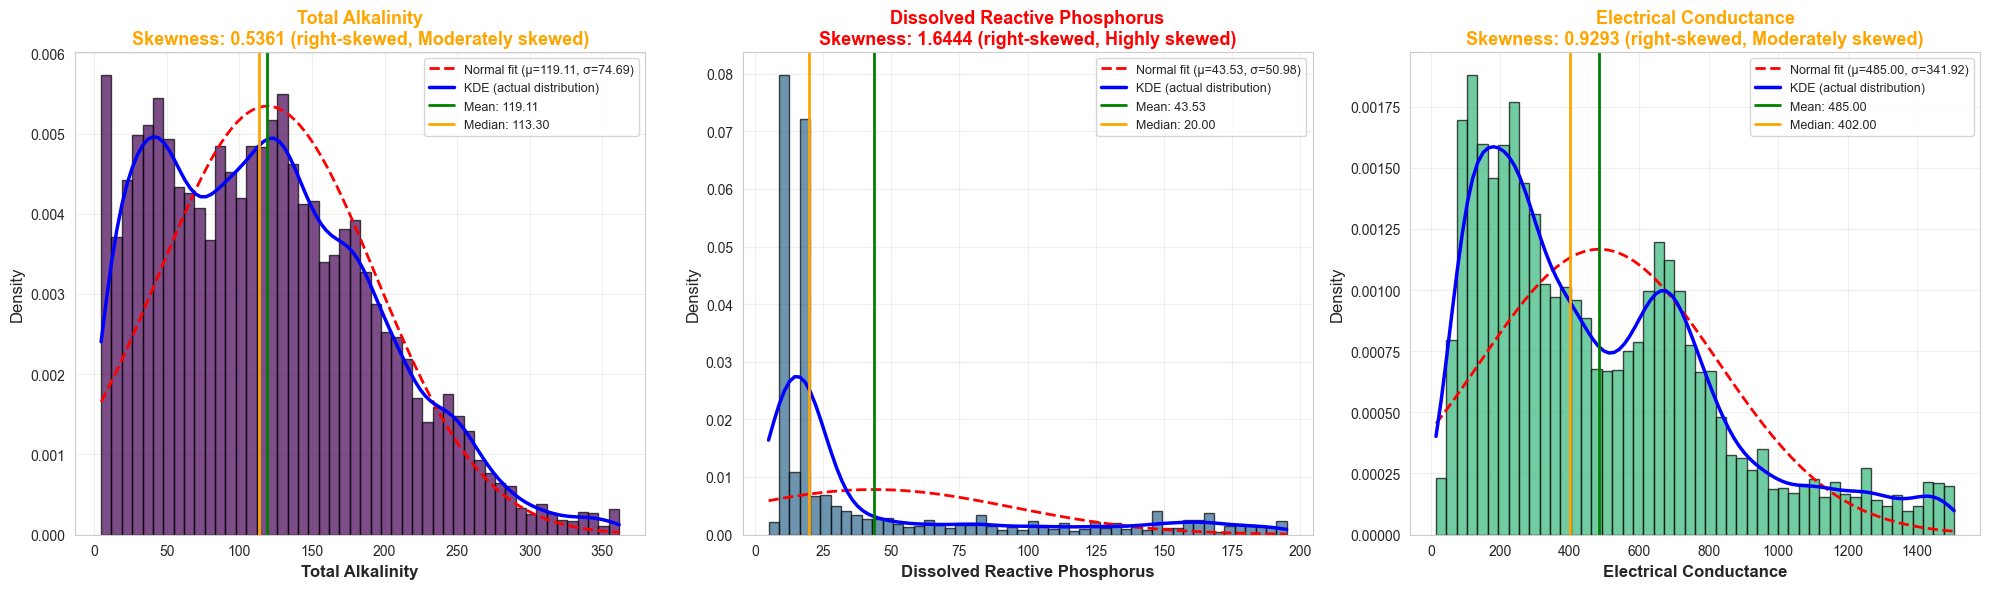


SUMMARY COMPARISON

                       Feature Skewness Kurtosis   Mean Median    Std
             Total Alkalinity   0.5361  -0.2529 119.11 113.30  74.69
Dissolved Reactive Phosphorus   1.6444   1.3324  43.53  20.00  50.98
       Electrical Conductance   0.9293   0.2893 485.00 402.00 341.94

Note: Positive skewness = right tail, Negative skewness = left tail


In [11]:
# Create histograms with skewness curves for each feature

# Features to analyze
features = {
    'Total Alkalinity': 'Total Alkalinity',
    'Dissolved Reactive Phosphorus': 'Dissolved Reactive Phosphorus',
    'Electrical Conductance': 'Electrical Conductance'
}

# Create figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, (feature_name, column_name) in enumerate(features.items()):
    # Get data, removing missing values
    data = water_quality[column_name].dropna()
    
    # Calculate skewness
    skewness = stats.skew(data)
    
    # Create histogram
    n, bins, patches = axes[idx].hist(data, bins=50, density=True, alpha=0.7, 
                                      edgecolor='black', color=plt.cm.viridis(idx/3))
    
    # Fit a normal distribution to the data for comparison
    mu, sigma = stats.norm.fit(data)
    x = np.linspace(data.min(), data.max(), 100)
    normal_curve = stats.norm.pdf(x, mu, sigma)
    
    # Plot normal distribution curve
    axes[idx].plot(x, normal_curve, 'r--', linewidth=2, label=f'Normal fit (μ={mu:.2f}, σ={sigma:.2f})')
    
    # Create a kernel density estimate (KDE) curve to show actual distribution shape
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(data)
    kde_x = np.linspace(data.min(), data.max(), 100)
    kde_curve = kde(kde_x)
    axes[idx].plot(kde_x, kde_curve, 'b-', linewidth=2.5, label='KDE (actual distribution)')
    
    # Add mean and median lines
    mean_val = data.mean()
    median_val = data.median()
    axes[idx].axvline(mean_val, color='green', linestyle='-', linewidth=2, 
                      label=f'Mean: {mean_val:.2f}')
    axes[idx].axvline(median_val, color='orange', linestyle='-', linewidth=2, 
                      label=f'Median: {median_val:.2f}')
    
    # Customize plot
    axes[idx].set_xlabel(feature_name, fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Density', fontsize=12)
    
    # Determine skewness interpretation
    if abs(skewness) < 0.5:
        skew_interpretation = "≈ Symmetric"
        color = 'green'
    elif abs(skewness) < 1:
        skew_interpretation = "Moderately skewed"
        color = 'orange'
    else:
        skew_interpretation = "Highly skewed"
        color = 'red'
    
    direction = "right" if skewness > 0 else "left"
    title = f'{feature_name}\nSkewness: {skewness:.4f} ({direction}-skewed, {skew_interpretation})'
    axes[idx].set_title(title, fontsize=13, fontweight='bold', color=color)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(fontsize=9, loc='best')
    
    # Print statistics
    print(f"\n{'='*70}")
    print(f"{feature_name.upper()}")
    print(f"{'='*70}")
    print(f"  Count: {len(data)}")
    print(f"  Mean: {mean_val:.4f}")
    print(f"  Median: {median_val:.4f}")
    print(f"  Std: {data.std():.4f}")
    print(f"  Min: {data.min():.4f}")
    print(f"  Max: {data.max():.4f}")
    print(f"  Skewness: {skewness:.4f} ({direction}-skewed)")
    print(f"  Kurtosis: {stats.kurtosis(data):.4f}")
    if abs(mean_val - median_val) > 0.01 * mean_val:
        print(f"  Mean-Median difference: {abs(mean_val - median_val):.4f} "
              f"({abs(mean_val - median_val)/mean_val*100:.2f}% of mean)")

plt.tight_layout()
plt.show()

# Summary comparison
print("\n" + "="*70)
print("SUMMARY COMPARISON")
print("="*70)
summary_data = []
for feature_name, column_name in features.items():
    data = water_quality[column_name].dropna()
    summary_data.append({
        'Feature': feature_name,
        'Skewness': f"{stats.skew(data):.4f}",
        'Kurtosis': f"{stats.kurtosis(data):.4f}",
        'Mean': f"{data.mean():.2f}",
        'Median': f"{data.median():.2f}",
        'Std': f"{data.std():.2f}"
    })

summary_df = pd.DataFrame(summary_data)
print("\n", summary_df.to_string(index=False))
print("\nNote: Positive skewness = right tail, Negative skewness = left tail")


Total Alkalinity:
  Total samples: 9319
  Latitude range: [-34.41, -22.23]
  Longitude range: [17.73, 32.33]
  Feature range: [4.80, 361.68]
  Mean Total Alkalinity: 119.11

Dissolved Reactive Phosphorus:
  Total samples: 9319
  Latitude range: [-34.41, -22.23]
  Longitude range: [17.73, 32.33]
  Feature range: [5.00, 195.00]
  Mean Dissolved Reactive Phosphorus: 43.53

Electrical Conductance:
  Total samples: 9319
  Latitude range: [-34.41, -22.23]
  Longitude range: [17.73, 32.33]
  Feature range: [15.12, 1506.00]
  Mean Electrical Conductance: 485.00


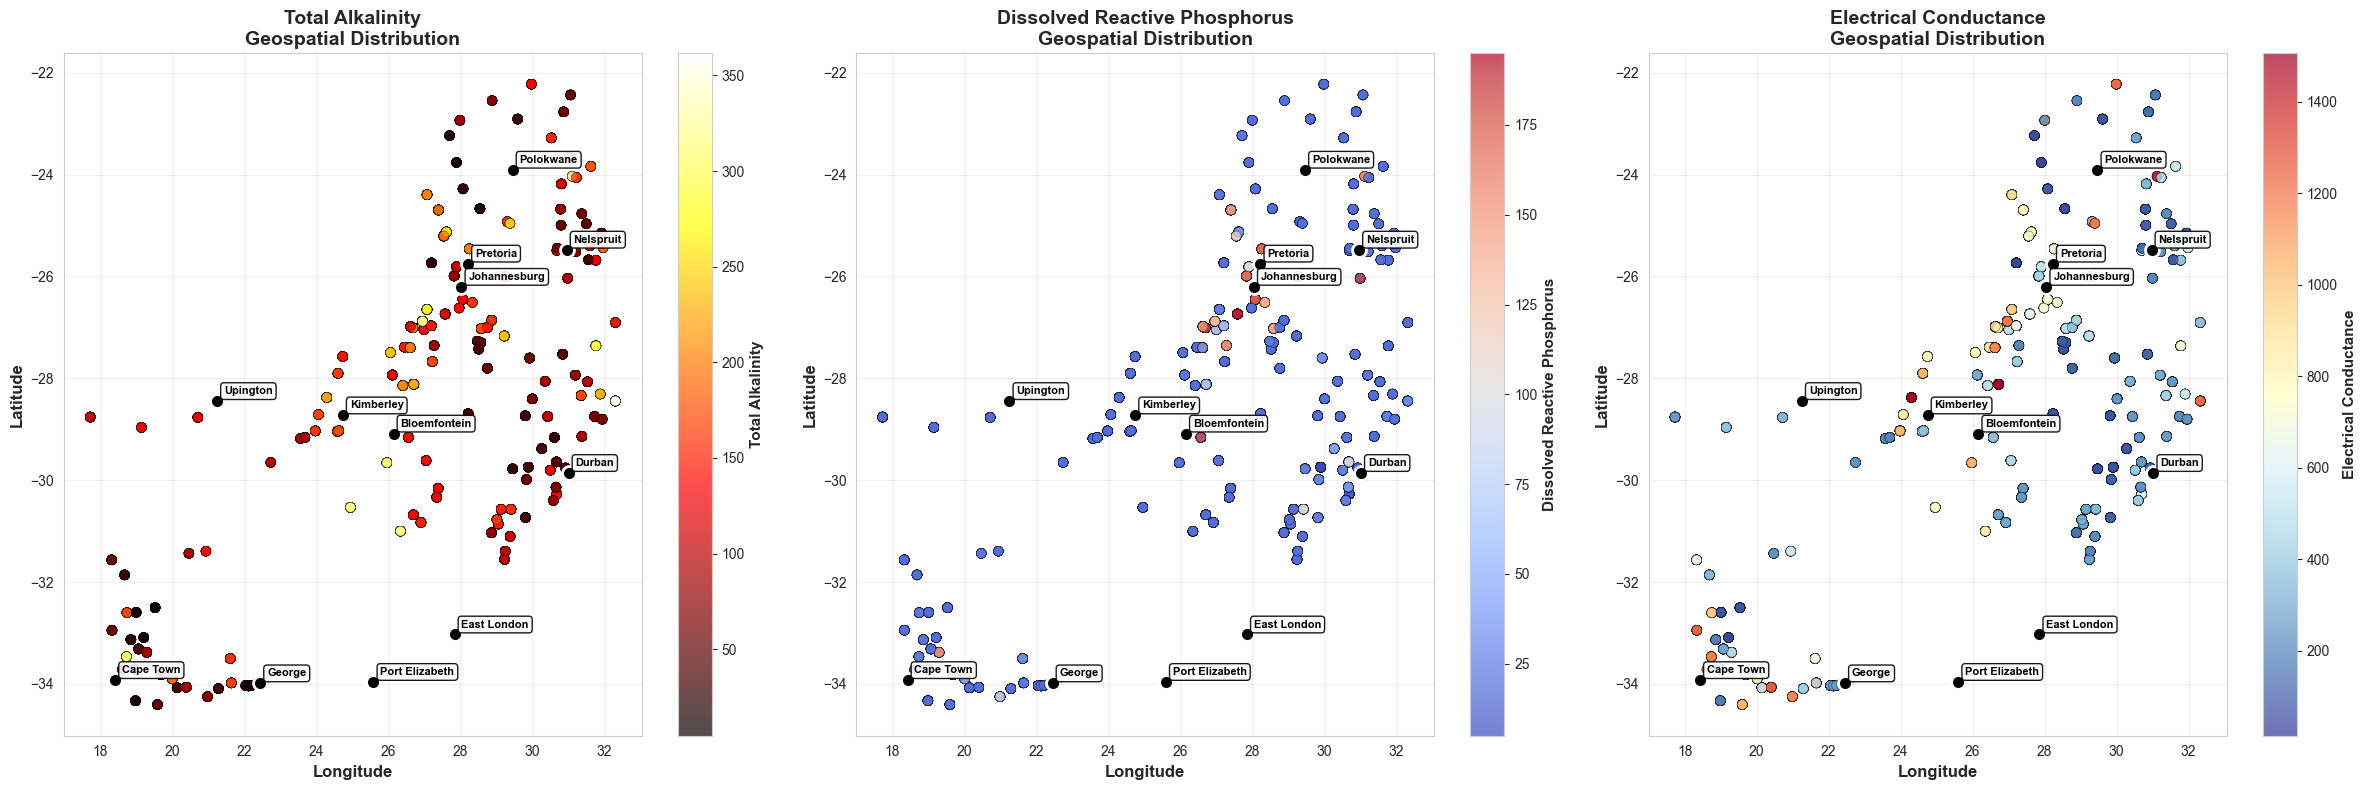


Geospatial heat maps created successfully!


In [12]:
# Create scatterplot geospatial heat maps for the three water quality features

# Clean data - remove rows with missing coordinates or feature values
water_quality_clean = water_quality.dropna(subset=['Latitude', 'Longitude'])

# Define prominent South African cities with their coordinates
south_african_cities = {
    'Cape Town': [-33.9249, 18.4241],
    'Johannesburg': [-26.2041, 28.0473],
    'Durban': [-29.8587, 31.0218],
    'Pretoria': [-25.7479, 28.2293],
    'Port Elizabeth': [-33.9608, 25.6022],
    'Bloemfontein': [-29.0852, 26.1596],
    'East London': [-33.0292, 27.8546],
    'Polokwane': [-23.9045, 29.4689],
    'Nelspruit': [-25.4745, 30.9703],
    'Kimberley': [-28.7282, 24.7497],
    'George': [-33.9881, 22.4536],
    'Upington': [-28.4478, 21.2561]
}

# Features to visualize
features = {
    'Total Alkalinity': 'Total Alkalinity',
    'Dissolved Reactive Phosphorus': 'Dissolved Reactive Phosphorus',
    'Electrical Conductance': 'Electrical Conductance'
}

# Create figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Color maps for each feature - using high contrast colormaps
colormaps = ['hot', 'coolwarm', 'RdYlBu_r']

for idx, (feature_name, column_name) in enumerate(features.items()):
    # Get data with valid coordinates and feature values
    plot_data = water_quality_clean.dropna(subset=[column_name])
    
    # Create scatter plot colored by feature values - larger dots with better contrast
    scatter = axes[idx].scatter(plot_data['Longitude'], 
                                plot_data['Latitude'], 
                                c=plot_data[column_name], 
                                cmap=colormaps[idx], 
                                s=50, 
                                alpha=0.7, 
                                edgecolors='black',
                                linewidths=0.3)
    
    # Add city markers - make them more visible
    for city_name, (lat, lon) in south_african_cities.items():
        axes[idx].plot(lon, lat, 'ko', markersize=10, markeredgecolor='white', markeredgewidth=2)
        axes[idx].annotate(city_name, (lon, lat), xytext=(5, 5), textcoords='offset points', 
                          fontsize=8, fontweight='bold', color='black',
                          bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9, edgecolor='black'))
    
    # Customize plot
    axes[idx].set_xlabel('Longitude', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Latitude', fontsize=12, fontweight='bold')
    axes[idx].set_title(f'{feature_name}\nGeospatial Distribution', fontsize=14, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=axes[idx])
    cbar.set_label(feature_name, fontsize=11, fontweight='bold')
    
    # Print statistics
    print(f"\n{feature_name}:")
    print(f"  Total samples: {len(plot_data)}")
    print(f"  Latitude range: [{plot_data['Latitude'].min():.2f}, {plot_data['Latitude'].max():.2f}]")
    print(f"  Longitude range: [{plot_data['Longitude'].min():.2f}, {plot_data['Longitude'].max():.2f}]")
    print(f"  Feature range: [{plot_data[column_name].min():.2f}, {plot_data[column_name].max():.2f}]")
    print(f"  Mean {feature_name}: {plot_data[column_name].mean():.2f}")

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("Geospatial heat maps created successfully!")
print("="*70)

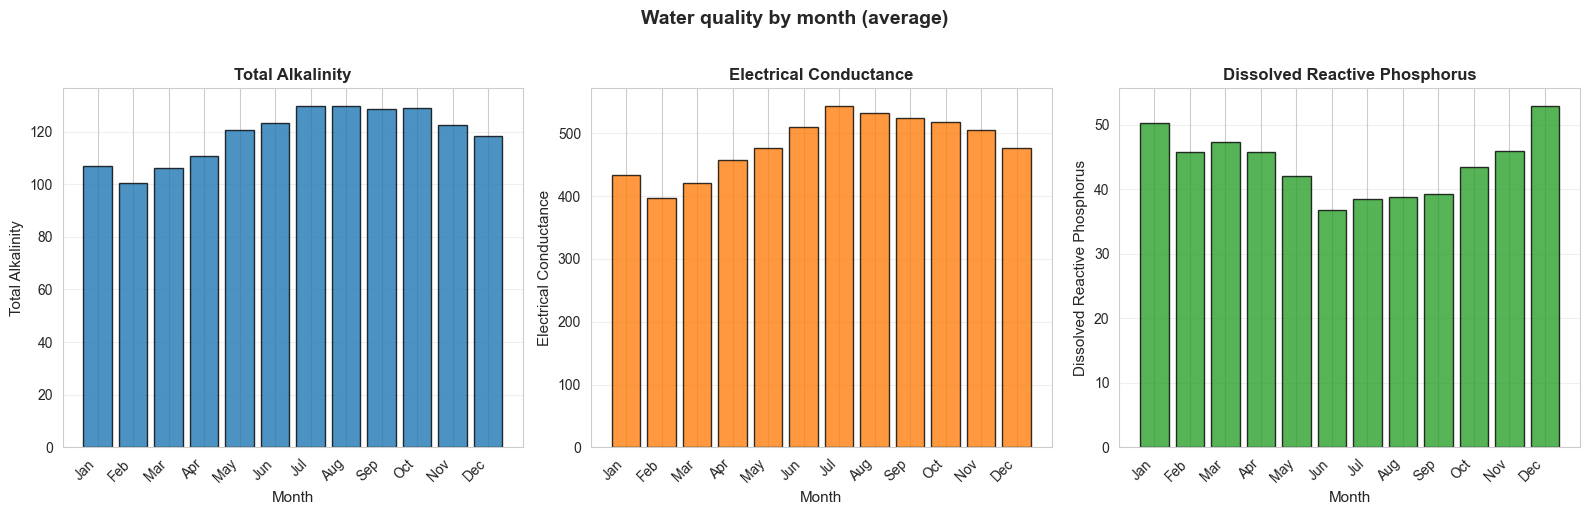

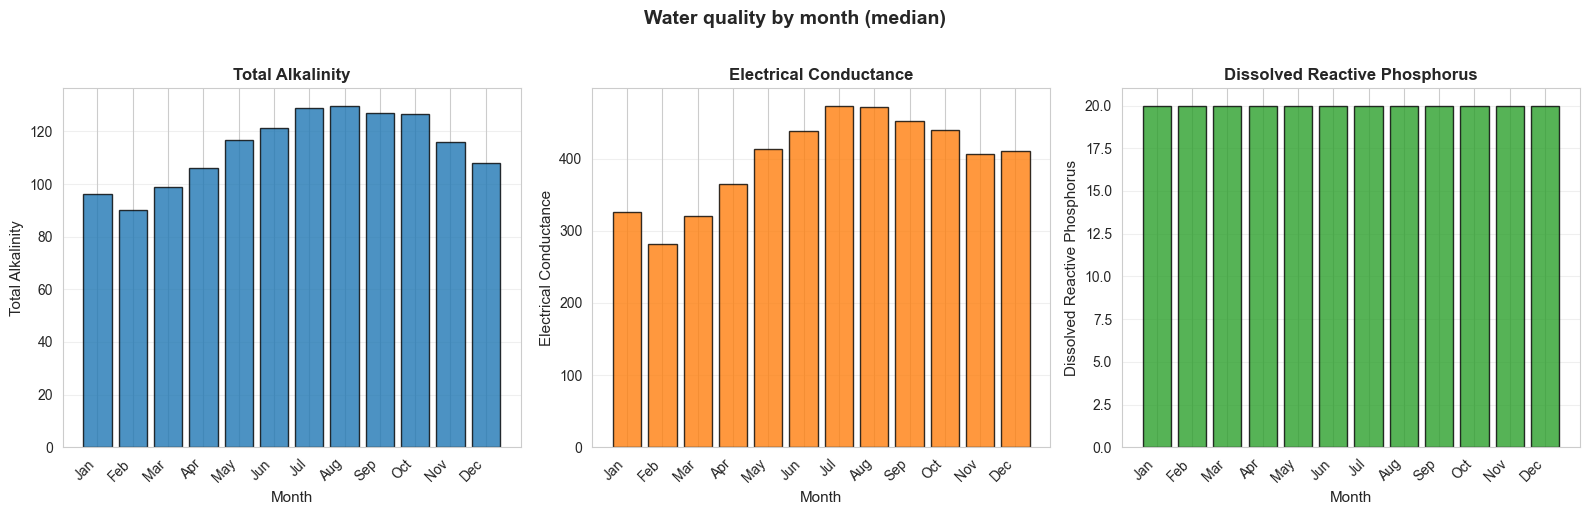

In [9]:
# How DRP, EC, and Total Alkalinity change by month (average and median)

# Parse sample date and extract month (assume DD-MM-YYYY)
water_quality['Sample Date'] = pd.to_datetime(water_quality['Sample Date'], dayfirst=True, errors='coerce')
water_quality['Month'] = water_quality['Sample Date'].dt.month

# Drop rows with missing date or feature values for this analysis
cols = ['Month', 'Total Alkalinity', 'Electrical Conductance', 'Dissolved Reactive Phosphorus']
df_month = water_quality[cols].dropna()

# Aggregate by month: average and median
by_month_mean = df_month.groupby('Month')[['Total Alkalinity', 'Electrical Conductance', 'Dissolved Reactive Phosphorus']].mean()
by_month_median = df_month.groupby('Month')[['Total Alkalinity', 'Electrical Conductance', 'Dissolved Reactive Phosphorus']].median()

# Month names for x-axis
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
x_months = np.arange(1, 13)
x_labels = [month_names[i-1] for i in x_months]

# --- Figure 1: Average by month (one subplot per feature) ---
fig1, axes1 = plt.subplots(1, 3, figsize=(16, 5))
fig1.suptitle('Water quality by month (average)', fontsize=14, fontweight='bold', y=1.02)

features = [
    ('Total Alkalinity', 'Total Alkalinity', 'C0'),
    ('Electrical Conductance', 'Electrical Conductance', 'C1'),
    ('Dissolved Reactive Phosphorus', 'Dissolved Reactive Phosphorus', 'C2')
]
for ax, (title, col, color) in zip(axes1, features):
    ser = by_month_mean.reindex(x_months)[col]
    ax.bar(ser.index, ser.values, color=color, edgecolor='black', alpha=0.8)
    ax.set_xticks(x_months)
    ax.set_xticklabels(x_labels, rotation=45, ha='right')
    ax.set_ylabel(title, fontsize=11)
    ax.set_xlabel('Month', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# --- Figure 2: Median by month (one subplot per feature) ---
fig2, axes2 = plt.subplots(1, 3, figsize=(16, 5))
fig2.suptitle('Water quality by month (median)', fontsize=14, fontweight='bold', y=1.02)

for ax, (title, col, color) in zip(axes2, features):
    ser = by_month_median.reindex(x_months)[col]
    ax.bar(ser.index, ser.values, color=color, edgecolor='black', alpha=0.8)
    ax.set_xticks(x_months)
    ax.set_xticklabels(x_labels, rotation=45, ha='right')
    ax.set_ylabel(title, fontsize=11)
    ax.set_xlabel('Month', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

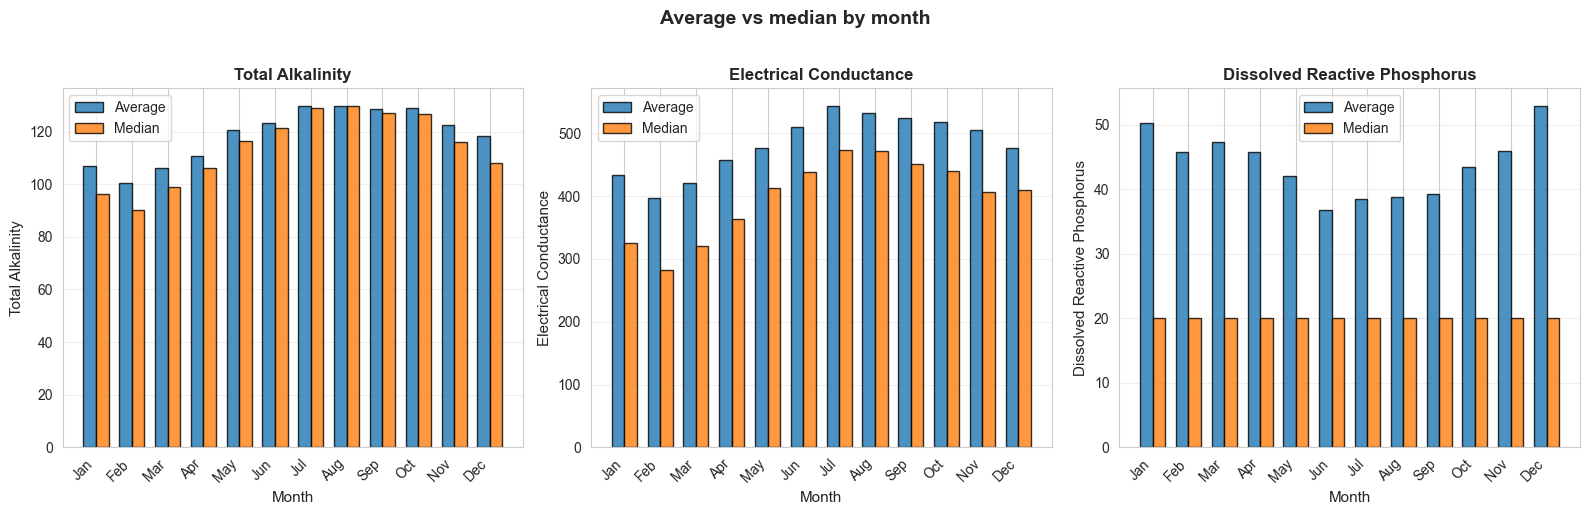

In [10]:
# Third view: average vs median by month (side-by-side for each feature)
fig3, axes3 = plt.subplots(1, 3, figsize=(16, 5))
fig3.suptitle('Average vs median by month', fontsize=14, fontweight='bold', y=1.02)

x = np.arange(len(x_months))
width = 0.35

for ax, (title, col, _) in zip(axes3, features):
    mean_vals = by_month_mean.reindex(x_months)[col].values
    median_vals = by_month_median.reindex(x_months)[col].values
    ax.bar(x - width/2, mean_vals, width, label='Average', color='C0', alpha=0.8, edgecolor='black')
    ax.bar(x + width/2, median_vals, width, label='Median', color='C1', alpha=0.8, edgecolor='black')
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=45, ha='right')
    ax.set_ylabel(title, fontsize=11)
    ax.set_xlabel('Month', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

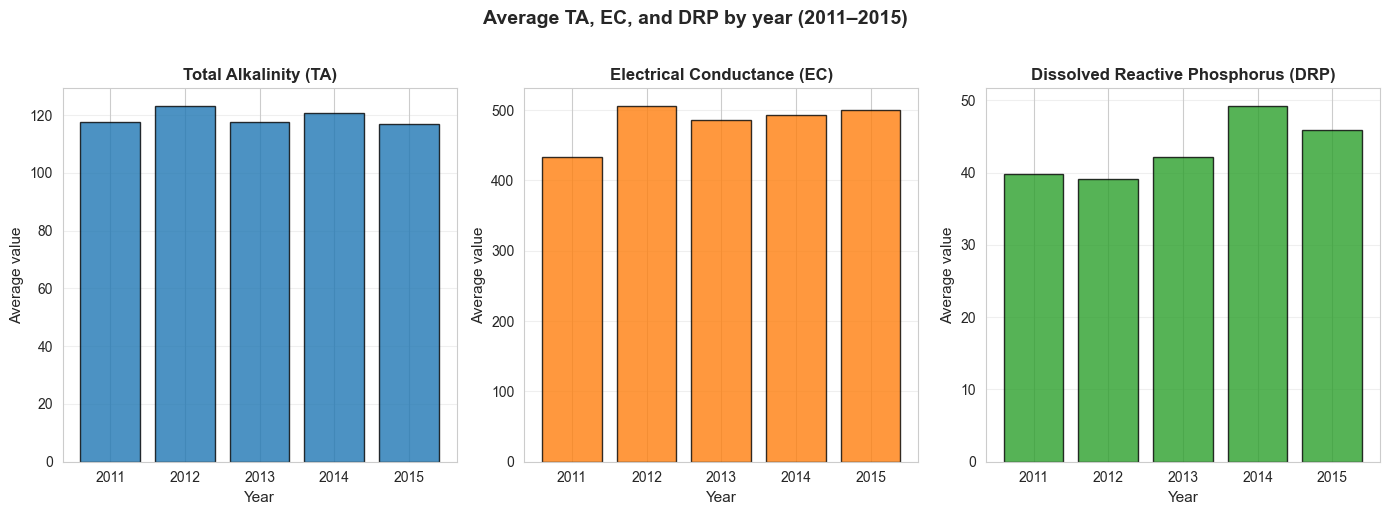

Average by year:
      Total Alkalinity  Electrical Conductance  Dissolved Reactive Phosphorus
Year                                                                         
2011            117.46                  432.56                          39.76
2012            123.05                  505.42                          39.17
2013            117.46                  486.33                          42.13
2014            120.79                  492.68                          49.19
2015            116.74                  500.35                          45.91


In [13]:
# Average distribution of TA, EC, and DRP by year (2011–2015)

# Ensure Sample Date is datetime and add Year
water_quality['Sample Date'] = pd.to_datetime(water_quality['Sample Date'], dayfirst=True, errors='coerce')
water_quality['Year'] = water_quality['Sample Date'].dt.year

# Restrict to 2011–2015
cols = ['Year', 'Total Alkalinity', 'Electrical Conductance', 'Dissolved Reactive Phosphorus']
df_year = water_quality[cols].dropna()
df_year = df_year[(df_year['Year'] >= 2011) & (df_year['Year'] <= 2015)]

# Average by year
by_year_mean = df_year.groupby('Year')[['Total Alkalinity', 'Electrical Conductance', 'Dissolved Reactive Phosphorus']].mean()

years = by_year_mean.index.tolist()
x_pos = np.arange(len(years))

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Average TA, EC, and DRP by year (2011–2015)', fontsize=14, fontweight='bold', y=1.02)

features = [
    ('Total Alkalinity (TA)', 'Total Alkalinity', 'C0'),
    ('Electrical Conductance (EC)', 'Electrical Conductance', 'C1'),
    ('Dissolved Reactive Phosphorus (DRP)', 'Dissolved Reactive Phosphorus', 'C2')
]

for ax, (title, col, color) in zip(axes, features):
    vals = by_year_mean[col].values
    ax.bar(x_pos, vals, color=color, edgecolor='black', alpha=0.8)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(years)
    ax.set_ylabel('Average value', fontsize=11)
    ax.set_xlabel('Year', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Optional: print yearly averages
print('Average by year:')
print(by_year_mean.round(2))

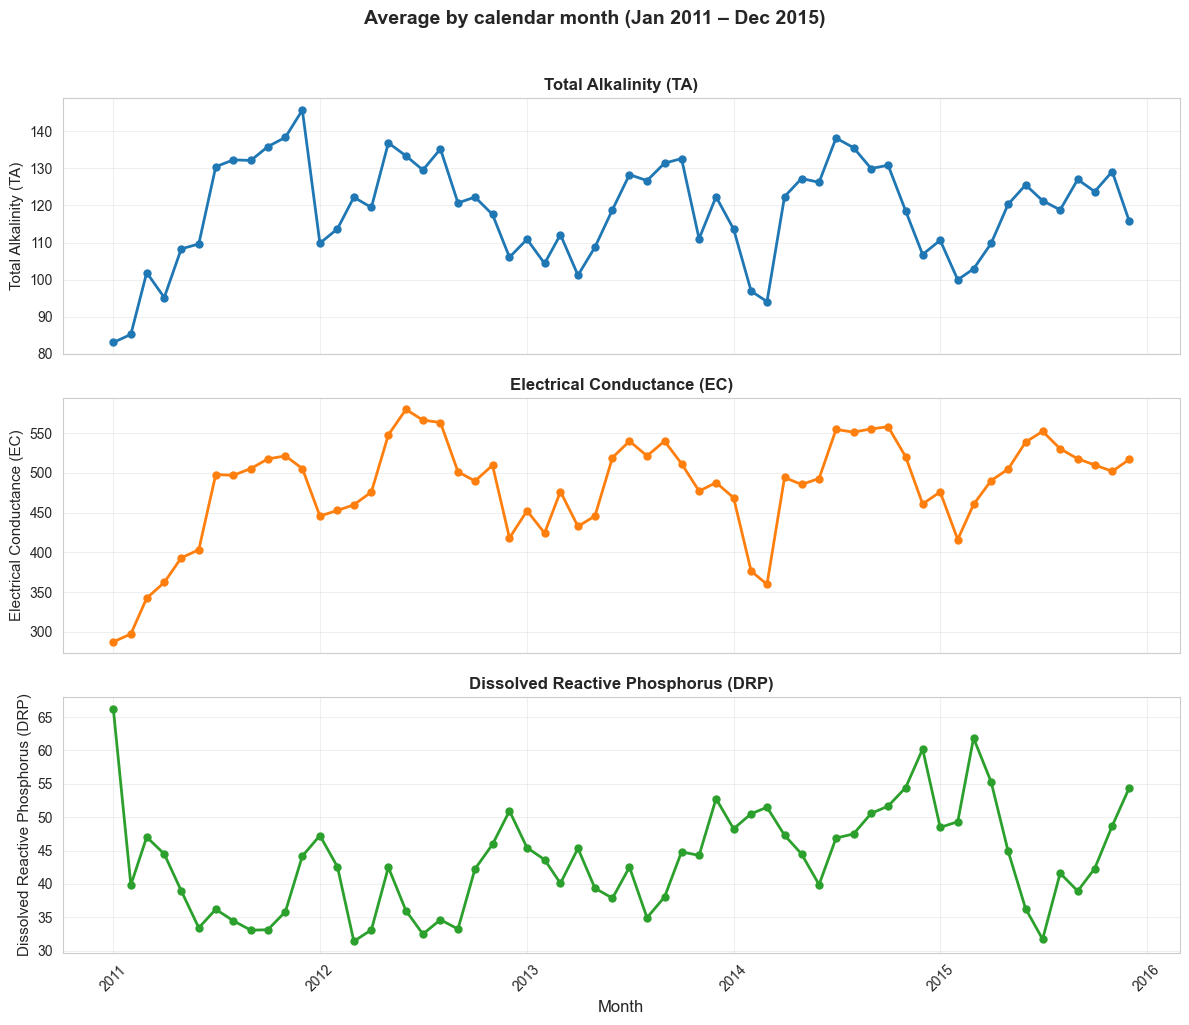

In [15]:
# Line plots: average TA, EC, and DRP per calendar month (Jan 2011 → Dec 2015)

from matplotlib.lines import Line2D

water_quality['Sample Date'] = pd.to_datetime(water_quality['Sample Date'], dayfirst=True, errors='coerce')
water_quality['Month'] = water_quality['Sample Date'].dt.month
water_quality['Year'] = water_quality['Sample Date'].dt.year

# Restrict to 2011–2015
cols = ['Year', 'Month', 'Total Alkalinity', 'Electrical Conductance', 'Dissolved Reactive Phosphorus']
df = water_quality[cols].dropna()
df = df[(df['Year'] >= 2011) & (df['Year'] <= 2015)]

# One row per (Year, Month): average of each feature
by_ym = df.groupby(['Year', 'Month'])[['Total Alkalinity', 'Electrical Conductance', 'Dissolved Reactive Phosphorus']].mean().reset_index()

# Build time order: Jan 2011, Feb 2011, ..., Dec 2015
by_ym['Period'] = by_ym['Year'].astype(str) + '-' + by_ym['Month'].astype(str).str.zfill(2)
by_ym = by_ym.sort_values(['Year', 'Month'])
x_dates = pd.to_datetime(by_ym['Period'] + '-01')

# Dates to mark: Feb and June for TA/EC; May and Sept for DRP
feb_dates = x_dates[by_ym['Month'] == 2]
june_dates = x_dates[by_ym['Month'] == 6]
may_dates = x_dates[by_ym['Month'] == 5]
sep_dates = x_dates[by_ym['Month'] == 9]

features = [
    ('Total Alkalinity (TA)', 'Total Alkalinity', 'C0'),
    ('Electrical Conductance (EC)', 'Electrical Conductance', 'C1'),
    ('Dissolved Reactive Phosphorus (DRP)', 'Dissolved Reactive Phosphorus', 'C2')
]

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle('Average by calendar month (Jan 2011 – Dec 2015)', fontsize=14, fontweight='bold', y=1.02)

for i, (ax, (title, col, color)) in enumerate(zip(axes, features)):
    ax.plot(x_dates, by_ym[col], marker='o', linewidth=2, markersize=5, color=color)
    # TA and EC: mark Feb and June
    if i in (0, 1):
        for d in feb_dates:
            ax.axvline(d, color='navy', linestyle='--', alpha=0.6, linewidth=1)
        for d in june_dates:
            ax.axvline(d, color='darkorange', linestyle='--', alpha=0.6, linewidth=1)
        ax.legend(handles=[
            Line2D([0], [0], color='navy', linestyle='--', linewidth=2, label='Feb'),
            Line2D([0], [0], color='darkorange', linestyle='--', linewidth=2, label='June')
        ], loc='upper right', fontsize=9)
    # DRP: mark May and September
    else:
        for d in may_dates:
            ax.axvline(d, color='green', linestyle='--', alpha=0.6, linewidth=1)
        for d in sep_dates:
            ax.axvline(d, color='purple', linestyle='--', alpha=0.6, linewidth=1)
        ax.legend(handles=[
            Line2D([0], [0], color='green', linestyle='--', linewidth=2, label='May'),
            Line2D([0], [0], color='purple', linestyle='--', linewidth=2, label='Sept')
        ], loc='upper right', fontsize=9)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

axes[-1].set_xlabel('Month', fontsize=12)
plt.tight_layout()
plt.show()